# Cell assembly and steady-state polarization curve

This notebook is a minimal example of the `marapendi` API: it assembles a
single :class:`~marapendi.cell.Cell` from its components (membrane, catalyst
layers, gas diffusion layers, flow channels), defines operating conditions
with :class:`~marapendi.conditions.CellOperatingConditions`, and computes a
steady-state polarization curve with
:class:`~marapendi.model.ExplicitSteadyStateModel`.

The cell parameters below correspond to the 18-parameter estimation result
for MEA62 (condition 2: 50 °C, 2.5 bar, 50 % RH) from
`results/results_final_estimation_model2_new_perm_lim_cv.csv`, combined with
the fixed parameters used in
`parameter_estimation_Affonso_Nobrega_et_al_2026_JES.ipynb`. See that
notebook for the full parameter-estimation workflow.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from marapendi.electrochemistry import ElectrochemicalReaction
from marapendi.ionomer import PFSAIonomer
from marapendi.membrane_permeation_models import HydrogenPermeationModel
from marapendi.transport_models import ChannelGasResistanceModel, DarcyTransportModel, PorousGasResistanceModel
from marapendi.cell import Cell, CellSide
from marapendi.catalyst_layers import PtCCatalystLayer
from marapendi.conditions import CellOperatingConditions, SideOperatingConditions
from marapendi.flow_channels import FlowChannel
from marapendi.membrane import PFSA
from marapendi.model import ExplicitSteadyStateModel
from marapendi.porous_layers import GasDiffusionLayer

## 1 — Cell parameters

Fixed parameters (Table I of the paper) plus the 18 parameters estimated for MEA62, condition 2 (50 °C, 2.5 bar, 50 % RH).

In [2]:
# Fixed parameters, from parameter_estimation_Affonso_Nobrega_et_al_2026_JES.ipynb.
fixed_parameters = {
    'radius-carbon': 25e-9,
    'ionomer-E-act-cond': 15e6,
    'n_s': 2,
    'ionomer-k1': 8.5,
    'ionomer-k2': 5.4,
    'ionomer-k3': 5.4,
    'gdl-porosity': 0.6,
    'pt-wt-percent': 0.4,
    'ch-height': 1e-3,
    'gdl-thickness': 150e-6,
    'gdl-theta': 120.,
    'gdl-eff-diff-ratio': 0.3,
    'cl-abs-perm': 1e-13,
    'wet-transition': 0.4,
    'pt-loading': .3e-2,
    'ic-ratio': 1.4,
    'ecsa': 60e3,
    'memb-thickness': 12e-6,
    'memb-water-diff': 2e-10,
    'E-act-memb-diff': 20e6,
    'E-act-memb-abs': 20e6,
    'cl-theta': 97.,
    'cl-thermal-cond': 0.22,
    'cl-pore-diameter': 40e-9,
}

# 18 parameters estimated for MEA62, condition 2 (50 degC, 2.5 bar, 50 % RH),
# from results/results_final_estimation_model2_new_perm_lim_cv.csv (n_parameters=18, test_case=2).
estimated_parameters = {
    'elec-resistance': 3.054915101703709e-06,
    'alpha-c': 0.9775899809663552,
    'memb-cond-correction': 1.5922499465376831,
    'B_ch': 1.80325792169269,
    'ionomer-cond-corr': 0.1316812631056596,
    'i0-c': 0.0004699927200932,
    'memb-cond-exp': 1.0173296016593392,
    'Sh': 1.2729802151294305,
    'E-act-ca': 78134052.29130368,
    'memb-equiv-weight': 1094.6751018523782,
    'memb-E-act-cond': 30000000.0,
    'gdl-thermal-cond': 0.0506508444021681,
    'gamma-c': 0.7704130164990449,
    'memb-abs-constant': 9.938341630251407e-05,
    'ix-corr': 2.0,
    'ionomer-cond-exp': 1.0,
    'tcr': 0.000492138820288,
    'gdl-abs-perm': 9.999999010000095e-12,
}

params = {**fixed_parameters, **estimated_parameters}

## 2 — Cell assembly

`create_cell` maps the parameter dictionary onto `marapendi` component dataclasses: a `PFSA` membrane, `PtCCatalystLayer`s, `GasDiffusionLayer`s and `FlowChannel`s for each side, assembled into a `Cell`.

In [3]:
def create_cell(params):
    membrane = PFSA(
        equivalent_weight=params['memb-equiv-weight'],
        dry_density=2000.,
        dry_thickness=params['memb-thickness'],
        conductivity_exp=params['memb-cond-exp'],
        conductivity_activation_energy=params['memb-E-act-cond'],
        conductivity_correction=params['memb-cond-correction'],
        reference_water_diffusivity=params['memb-water-diff'],
        reference_absorption_coefficient=params['memb-abs-constant'],
        water_diffusivity_activation_energy=params['E-act-memb-diff'],
        water_absorption_activation_energy=params['E-act-memb-abs'],
        h2_permeation_model=HydrogenPermeationModel(
            permeability_correction_factor=params['ix-corr']),
    )

    orr_kinetics = ElectrochemicalReaction(
        reference_exchange_current_density=params['i0-c'],
        reaction_order=params['gamma-c'],
        activation_energy=params['E-act-ca'],
        reference_activity=1.01325e5,
        reference_temperature=353.15,
        number_of_electrons=1,
        charge_transfer_coeff=params['alpha-c'],
    )

    liq_model = DarcyTransportModel(J_function_exponent=params['wet-transition'])

    gdl = {
        side: GasDiffusionLayer(
            thickness=params['gdl-thickness'],
            contact_angle=params['gdl-theta'],
            effective_gas_diffusion_ratio=params['gdl-eff-diff-ratio'],
            absolute_permeability=params['gdl-abs-perm'],
            porosity=params['gdl-porosity'],
            thermal_conductivity=params['gdl-thermal-cond'],
            two_phase_transport_model=liq_model,
            transport_resistance_model=PorousGasResistanceModel(
                water_saturation_exponent=params['n_s']),
        ) for side in ['ca', 'an']
    }

    ch = {
        side: FlowChannel(
            height=params['ch-height'], width=1e-3, n_parallel=1, length=21 * 50e-3,
            reactant='o2' if side == 'ca' else 'h2',
            transport_resistance_model=ChannelGasResistanceModel(
                sherwood=params['Sh'], B_ch=params['B_ch']),
        ) for side in ['an', 'ca']
    }

    ionomer = PFSAIonomer(
        conductivity_correction=params['ionomer-cond-corr'],
        conductivity_exp=params['ionomer-cond-exp'],
        conductivity_activation_energy=params['ionomer-E-act-cond'],
    )

    ca_cl = PtCCatalystLayer(
        ecsa=params['ecsa'], platinum_loading=params['pt-loading'], ionomer=ionomer,
        catalyst_platinum_weight_percent=params['pt-wt-percent'],
        ionomer_to_carbon_ratio=params['ic-ratio'],
        ionomer_k1=params['ionomer-k1'], ionomer_k2=params['ionomer-k2'], ionomer_k3=params['ionomer-k3'],
        pore_diameter=params['cl-pore-diameter'], omega_PtO=0,
        carbon_agglomerate_radius=params['radius-carbon'],
        thickness=params['pt-loading'] * 2.8e-6 / 0.1e-2,
        absolute_permeability=params['cl-abs-perm'], contact_angle=params['cl-theta'],
        thermal_conductivity=params['cl-thermal-cond'], reaction=orr_kinetics,
        two_phase_transport_model=liq_model,
        transport_resistance_model=PorousGasResistanceModel(water_saturation_exponent=1.5),
    )

    an_cl = PtCCatalystLayer(
        ecsa=params['ecsa'], platinum_loading=1e-3,
        catalyst_platinum_weight_percent=params['pt-wt-percent'],
        ionomer_to_carbon_ratio=params['ic-ratio'], ionomer=ionomer,
        pore_diameter=params['cl-pore-diameter'], carbon_agglomerate_radius=params['radius-carbon'],
        thickness=2.8e-6, absolute_permeability=params['cl-abs-perm'], contact_angle=params['cl-theta'],
        thermal_conductivity=params['cl-thermal-cond'], two_phase_transport_model=liq_model,
        transport_resistance_model=PorousGasResistanceModel(water_saturation_exponent=1.5),
    )

    return Cell(
        electrical_resistance=params['elec-resistance'],
        area=25e-4,
        ca=CellSide(cl=ca_cl, gdl=gdl['ca'], has_gdl=True, has_mpl=False, ch=ch['ca'],
                    thermal_contact_resistance=params['tcr']),
        an=CellSide(cl=an_cl, gdl=gdl['an'], has_gdl=True, has_mpl=False, ch=ch['an'],
                    thermal_contact_resistance=params['tcr']),
        membrane=membrane,
    )


cell = create_cell(params)
model = ExplicitSteadyStateModel(cell=cell)

## 3 — Operating conditions and steady-state sweep

`current_density` may be an array: `ExplicitSteadyStateModel.steady_state_solution` evaluates every operating point in one vectorized call.

In [4]:
current_density = np.linspace(0.02, 2.0, 40) * 1e4  # A/m^2

conditions = CellOperatingConditions(
    current_density=current_density,
    cell_temperature=50 + 273.15,
    ca=SideOperatingConditions(outlet_pressure=2.5e5, relative_humidity=0.5,
                                dry_o2_mole_fraction=0.21, stoichiometry=2.0),
    an=SideOperatingConditions(outlet_pressure=2.5e5, relative_humidity=0.5,
                                dry_h2_mole_fraction=1.0, stoichiometry=1.5),
)

state = model.steady_state_solution(conditions)

/Users/paffonsonobrega/Documents/Development/marapendi/src/marapendi/model.py:101: RuntimeWarning: divide by zero encountered in divide
  side_conditions.stoichiometry * side_reactant_consumption[side_name] * self.cell.area


## 4 — Polarization and power-density curves

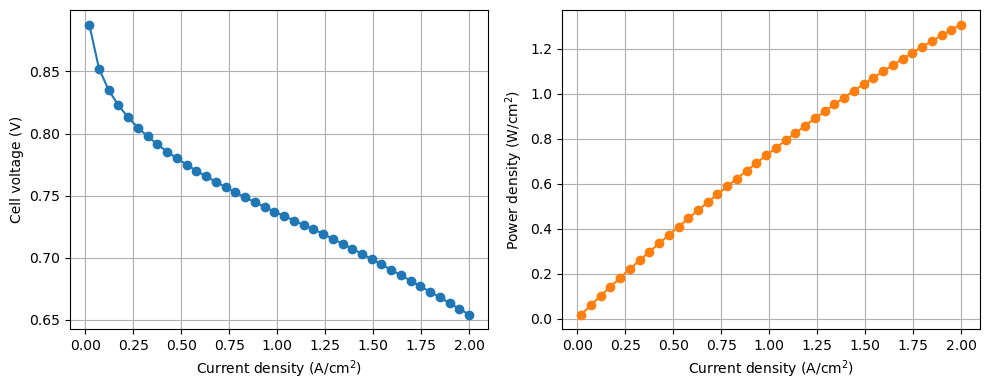

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(current_density * 1e-4, state.cell_voltage, 'o-')
ax1.set_xlabel('Current density (A/cm$^2$)')
ax1.set_ylabel('Cell voltage (V)')
ax1.grid()

power_density = current_density * 1e-4 * state.cell_voltage
ax2.plot(current_density * 1e-4, power_density, 'o-', color='C1')
ax2.set_xlabel('Current density (A/cm$^2$)')
ax2.set_ylabel('Power density (W/cm$^2$)')
ax2.grid()

fig.tight_layout()
plt.show()